# Monte Carlo Portfolio Risk Simulation

Este notebook implementa una simulacion de Monte Carlo para estimar el riesgo financiero de un portafolio de acciones reales.

El objetivo es generar cientos de miles de escenarios futuros posibles basados en datos historicos, y a partir de esa distribucion de resultados, calcular metricas de riesgo como VaR y CVaR.

El notebook esta diseñado para correr en Google Colab con GPU activada. Para activarla: Entorno de ejecucion > Cambiar tipo de entorno > GPU.

## 1. Instalacion de dependencias

Se instalan cuatro librerias:

- `yfinance`: descarga precios historicos de Yahoo Finance
- `cupy-cuda12x`: version de NumPy optimizada para GPU con CUDA. Si no hay GPU disponible, el codigo cae automaticamente a NumPy
- `tabulate`: formatea tablas en texto plano
- `matplotlib` y `seaborn`: visualizaciones

In [14]:
!pip install -q yfinance cupy-cuda12x tabulate seaborn

## 2. Verificacion del dispositivo

`nvidia-smi` muestra informacion de la GPU asignada por Colab. Si ves una tabla con modelo, memoria y temperatura, CUDA esta disponible y CuPy la usara automaticamente.

Si el comando no retorna nada, la sesion no tiene GPU. En ese caso el codigo igual funciona, solo mas lento.

In [15]:
!nvidia-smi

Tue May 19 04:42:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             30W /   70W |     207MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Imports y deteccion GPU/CPU

El bloque `try/except` intenta importar CuPy. Si lo encuentra, todas las operaciones numericas corren en GPU. Si no, usa NumPy en CPU. El resto del codigo no cambia en absoluto, porque CuPy tiene la misma API que NumPy.

Este patron se llama "backend agnostico" y es comun en codigo cientifico.

In [16]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
from tabulate import tabulate

try:
    import cupy as cp
    xp = cp
    DEVICE = "GPU (CuPy)"
except ImportError:
    xp = np
    DEVICE = "CPU (NumPy)"

print(f"Dispositivo activo: {DEVICE}")

Dispositivo activo: GPU (CuPy)


## 4. Configuracion del portafolio

Aqui defines los parametros principales de la simulacion:

- `TICKERS`: los simbolos de las acciones. Puedes cambiarlos por cualquier ticker valido de Yahoo Finance
- `WEIGHTS`: el porcentaje del capital invertido en cada accion. Deben sumar 1.0
- `PORTFOLIO_VALUE`: capital total en dolares
- `N_SIMULATIONS`: cuantos escenarios futuros generar. Mas simulaciones = mas precision, pero mas tiempo
- `HORIZON_DAYS`: cuantos dias hacia el futuro simular. 252 es un año bursatil
- `LOOKBACK_DAYS`: cuantos dias de historia usar para estimar parametros estadisticos
- `CONFIDENCE`: nivel de confianza para VaR y CVaR

In [17]:
TICKERS          = ["AAPL", "TSLA", "GOOGL", "MSFT", "AMZN"]
WEIGHTS          = [0.30,    0.20,   0.20,    0.15,   0.15  ]
PORTFOLIO_VALUE  = 100_000
N_SIMULATIONS    = 500_000
HORIZON_DAYS     = 252
LOOKBACK_DAYS    = 756
CONFIDENCE       = 0.95

assert abs(sum(WEIGHTS) - 1.0) < 1e-9, "Los pesos deben sumar 1.0"
assert len(TICKERS) == len(WEIGHTS), "Debe haber un peso por ticker"
print("Configuracion valida.")

Configuracion valida.


## 5. Descarga de datos historicos

`yfinance` descarga precios de cierre ajustados directamente de Yahoo Finance.

A partir de los precios calculamos los **retornos diarios**: el porcentaje de cambio de un dia al siguiente. Esta es la materia prima de la simulacion. No usamos precios directamente porque los retornos son estacionarios (no tienen tendencia de largo plazo que distorsione el analisis).

In [18]:
print(f"Descargando datos para: {', '.join(TICKERS)} ...")

raw     = yf.download(TICKERS, period=f"{LOOKBACK_DAYS}d", auto_adjust=True, progress=False)
prices  = raw["Close"].dropna()
returns = prices.pct_change().dropna()

print(f"Periodo: {prices.index[0].date()} a {prices.index[-1].date()}")
print(f"Dias de trading disponibles: {len(returns)}")
print()
print("Primeras filas de retornos diarios:")
print(returns.head())

Descargando datos para: AAPL, TSLA, GOOGL, MSFT, AMZN ...
Periodo: 2023-05-12 a 2026-05-18
Dias de trading disponibles: 755

Primeras filas de retornos diarios:
Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2023-05-15 -0.002897  0.008525 -0.008510  0.001586 -0.009703
2023-05-16  0.000000  0.019784  0.025749  0.007368  0.001022
2023-05-17  0.003603  0.018519  0.011129  0.009452  0.044079
2023-05-18  0.013666  0.022944  0.016468  0.014395  0.017428
2023-05-19  0.000629 -0.016081 -0.000570 -0.000565  0.018373


## 6. Estadisticas historicas

De los retornos historicos extraemos dos cosas:

**Media diaria** (`mu`): el retorno promedio de cada accion por dia.

**Matriz de covarianza** (`sigma`): captura no solo la volatilidad de cada accion, sino como se mueven juntas. Por ejemplo, si AAPL sube, MSFT tiende a subir tambien. Esta correlacion es critica para un portafolio real.

**Descomposicion de Cholesky** (`L`): es el paso matematico que permite generar numeros aleatorios que respeten esas correlaciones. Funciona como una raiz cuadrada de la matriz de covarianza.

In [19]:
mu    = returns.mean().values
sigma = returns.cov().values
L     = np.linalg.cholesky(sigma)

print("Retorno diario promedio por accion:")
for ticker, m in zip(TICKERS, mu):
    print(f"  {ticker}: {m*100:.4f}%  (anualizado: {m*252*100:.1f}%)")

print()
print("Volatilidad diaria (desviacion estandar):")
for ticker, s in zip(TICKERS, np.sqrt(np.diag(sigma))):
    print(f"  {ticker}: {s*100:.3f}%  (anualizada: {s*np.sqrt(252)*100:.1f}%)")

Retorno diario promedio por accion:
  AAPL: 0.0872%  (anualizado: 22.0%)
  TSLA: 0.1351%  (anualizado: 34.0%)
  GOOGL: 0.1797%  (anualizado: 45.3%)
  MSFT: 0.0559%  (anualizado: 14.1%)
  AMZN: 0.1838%  (anualizado: 46.3%)

Volatilidad diaria (desviacion estandar):
  AAPL: 1.622%  (anualizada: 25.8%)
  TSLA: 1.952%  (anualizada: 31.0%)
  GOOGL: 1.863%  (anualizada: 29.6%)
  MSFT: 1.484%  (anualizada: 23.6%)
  AMZN: 3.644%  (anualizada: 57.8%)


## 7. Visualizacion de correlaciones

El heatmap muestra la matriz de correlacion entre activos. Un valor de 1.0 significa movimiento identico, 0 significa independencia total, y valores negativos significan movimiento opuesto.

Activos muy correlacionados no diversifican bien el portafolio: si uno cae, el otro probablemente tambien.

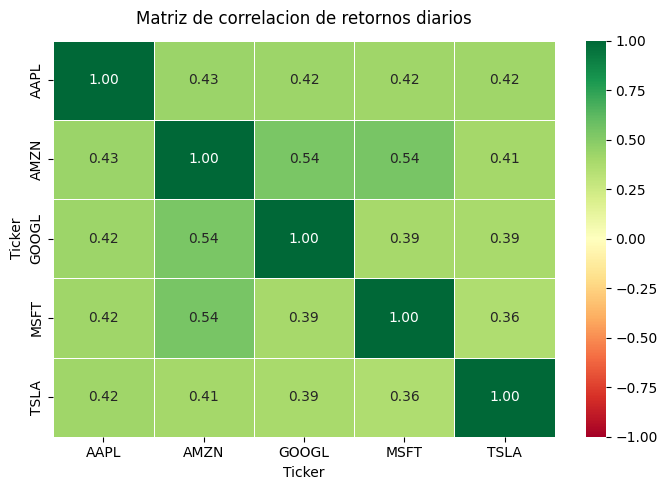

In [20]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Matriz de correlacion de retornos diarios", fontsize=12, pad=12)
plt.tight_layout()
plt.show()

## 8. Simulacion de Monte Carlo

Este es el nucleo del proyecto. Para cada simulacion y cada dia del horizonte:

1. Se generan numeros aleatorios con distribucion normal estandar (ruido puro)
2. Se multiplican por la matriz de Cholesky para introducir correlaciones reales
3. Se calculan los retornos diarios usando la formula de movimiento geometrico browniano: `mu - 0.5*varianza + ruido_correlacionado`
4. Se acumulan en log-espacio para evitar errores numericos
5. Al final del horizonte, se convierte a P&L en dolares

Todo esto corre en GPU si esta disponible. La GPU puede ejecutar miles de simulaciones en paralelo al mismo tiempo, mientras la CPU las haria de forma secuencial.

In [21]:
n_assets  = len(TICKERS)
w         = xp.array(WEIGHTS,  dtype=xp.float32)
mu_gpu    = xp.array(mu,        dtype=xp.float32)
L_gpu     = xp.array(L,         dtype=xp.float32)
var_diag  = xp.diag(L_gpu @ L_gpu.T)

log_cum = xp.zeros((N_SIMULATIONS, n_assets), dtype=xp.float32)

print(f"Corriendo {N_SIMULATIONS:,} simulaciones x {HORIZON_DAYS} dias en {DEVICE} ...")
t0 = time.perf_counter()

for day in range(HORIZON_DAYS):
    z          = xp.random.standard_normal((N_SIMULATIONS, n_assets)).astype(xp.float32)
    correlated = z @ L_gpu.T
    log_cum   += mu_gpu - 0.5 * var_diag + correlated

elapsed = time.perf_counter() - t0

# Convertir log-retornos acumulados a P&L en dolares
asset_returns   = xp.exp(log_cum) - 1
portfolio_ret   = asset_returns @ w
pnl_gpu         = portfolio_ret * PORTFOLIO_VALUE

# Mover resultado a CPU para analisis
pnl = xp.asnumpy(pnl_gpu) if xp is not np else pnl_gpu

print(f"Completado en {elapsed:.2f} segundos")
print(f"Escenarios generados: {len(pnl):,}")

Corriendo 500,000 simulaciones x 252 dias en GPU (CuPy) ...
Completado en 0.30 segundos
Escenarios generados: 500,000


## 9. Metricas de riesgo

Con la distribucion de P&L calculamos:

**VaR (Value at Risk)**: la perdida maxima que no se supera en el X% de los escenarios. Con 95% de confianza, el VaR responde: "en 19 de cada 20 escenarios, no pierdo mas que este monto".

**CVaR (Conditional VaR / Expected Shortfall)**: el promedio de las perdidas en el peor 5% de escenarios. Es mas conservador que el VaR y es la metrica exigida por regulacion bancaria Basel III porque captura mejor el riesgo de cola (los eventos extremos).

La diferencia clave: el VaR dice donde esta el umbral, el CVaR dice cuanto pierdes en promedio cuando lo cruzas.

In [22]:
sorted_pnl = np.sort(pnl)
alpha      = 1 - CONFIDENCE
var_idx    = int(alpha * len(pnl))

VaR  = -sorted_pnl[var_idx]
CVaR = -sorted_pnl[:var_idx].mean()

metrics = [
    ["Media P&L",             f"${pnl.mean():,.0f}"],
    ["Mediana P&L",           f"${np.median(pnl):,.0f}"],
    ["Desviacion estandar",   f"${pnl.std():,.0f}"],
    ["Mejor escenario",       f"${pnl.max():,.0f}"],
    ["Peor escenario",        f"${pnl.min():,.0f}"],
    [f"VaR {CONFIDENCE:.0%}", f"${VaR:,.0f}  ({VaR/PORTFOLIO_VALUE*100:.1f}% del portafolio)"],
    [f"CVaR {CONFIDENCE:.0%}",f"${CVaR:,.0f}  ({CVaR/PORTFOLIO_VALUE*100:.1f}% del portafolio)"],
]

print(tabulate(metrics, headers=["Metrica", "Valor"], tablefmt="rounded_outline"))

╭─────────────────────┬─────────────────────────────────╮
│ Metrica             │ Valor                           │
├─────────────────────┼─────────────────────────────────┤
│ Media P&L           │ $38,055                         │
│ Mediana P&L         │ $33,338                         │
│ Desviacion estandar │ $34,867                         │
│ Mejor escenario     │ $375,826                        │
│ Peor escenario      │ $-56,085                        │
│ VaR 95%             │ $9,769  (9.8% del portafolio)   │
│ CVaR 95%            │ $17,753  (17.8% del portafolio) │
╰─────────────────────┴─────────────────────────────────╯


## 10. Distribucion de resultados

El histograma muestra todos los escenarios simulados ordenados por resultado. La linea naranja es el VaR: todo lo que queda a su izquierda representa el peor 5% de casos. El area roja es donde vive el CVaR.

La forma de la distribucion es importante: si tiene cola larga hacia la izquierda (asimetria negativa), hay mas riesgo de perdidas extremas de lo que sugeririan modelos mas simples.

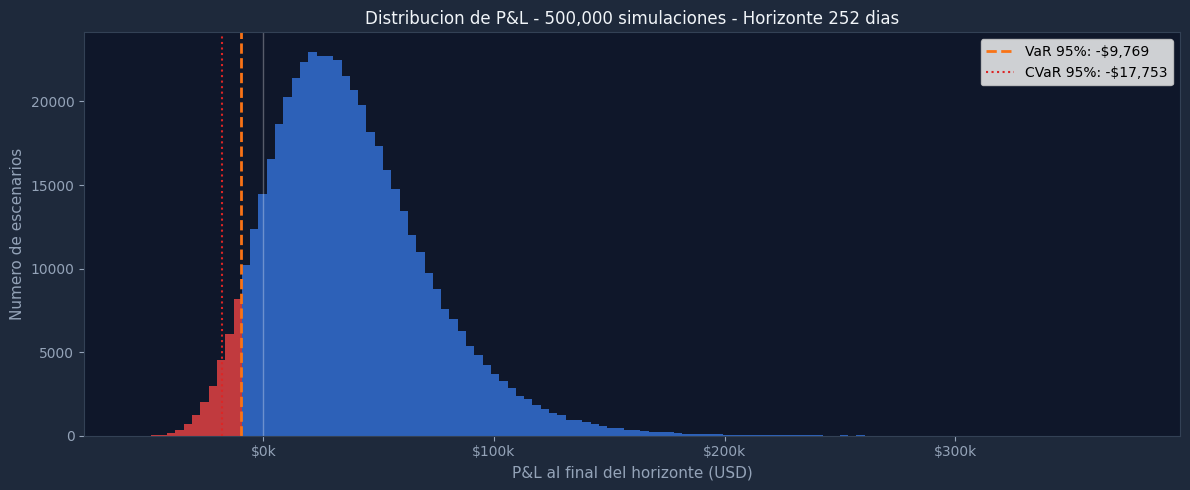

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

counts, bins, patches = ax.hist(pnl, bins=120, color="#3b82f6", alpha=0.7, edgecolor="none")

# Colorear la zona de perdida extrema (peor alpha%)
var_threshold = -VaR
for patch, left in zip(patches, bins[:-1]):
    if left < var_threshold:
        patch.set_facecolor("#ef4444")
        patch.set_alpha(0.8)

ax.axvline(var_threshold,  color="#f97316", linewidth=2, linestyle="--", label=f"VaR {CONFIDENCE:.0%}: -${VaR:,.0f}")
ax.axvline(-CVaR,          color="#dc2626", linewidth=1.5, linestyle=":", label=f"CVaR {CONFIDENCE:.0%}: -${CVaR:,.0f}")
ax.axvline(0,              color="white",   linewidth=1,   linestyle="-", alpha=0.3)

ax.set_xlabel("P&L al final del horizonte (USD)", fontsize=11)
ax.set_ylabel("Numero de escenarios", fontsize=11)
ax.set_title(f"Distribucion de P&L - {N_SIMULATIONS:,} simulaciones - Horizonte {HORIZON_DAYS} dias", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.legend(fontsize=10)
ax.set_facecolor("#0f172a")
fig.patch.set_facecolor("#1e293b")
ax.tick_params(colors="#94a3b8")
ax.xaxis.label.set_color("#94a3b8")
ax.yaxis.label.set_color("#94a3b8")
ax.title.set_color("#f1f5f9")
for spine in ax.spines.values():
    spine.set_edgecolor("#334155")

plt.tight_layout()
plt.show()

## 11. Composicion del portafolio

Este grafico muestra cuanto capital esta asignado a cada accion y cual es su contribucion al riesgo total estimado. Un activo con alta volatilidad y mucho peso puede dominar el riesgo del portafolio incluso si su retorno esperado es alto.

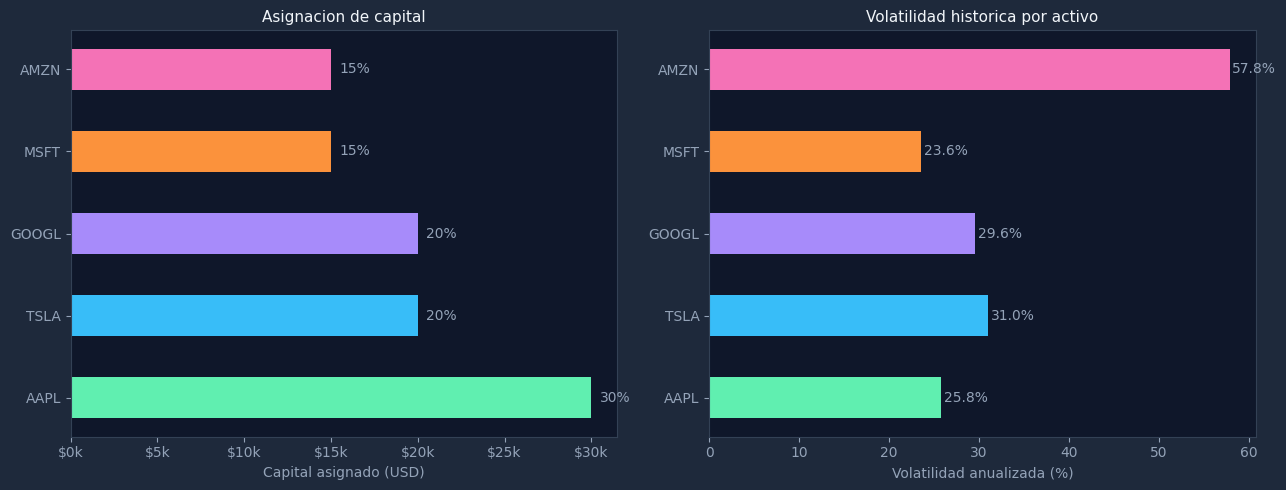

In [24]:
COLORS = ["#60efb0", "#38bdf8", "#a78bfa", "#fb923c", "#f472b6"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#1e293b")

# --- Grafico 1: Asignacion de capital ---
ax1 = axes[0]
bars = ax1.barh(TICKERS, [w * PORTFOLIO_VALUE for w in WEIGHTS], color=COLORS, height=0.5)
ax1.set_xlabel("Capital asignado (USD)", color="#94a3b8")
ax1.set_title("Asignacion de capital", color="#f1f5f9", fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax1.set_facecolor("#0f172a")
ax1.tick_params(colors="#94a3b8")
for spine in ax1.spines.values(): spine.set_edgecolor("#334155")
for bar, w in zip(bars, WEIGHTS):
    ax1.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f"{w*100:.0f}%", va="center", color="#94a3b8", fontsize=10)

# --- Grafico 2: Volatilidad anualizada por activo ---
vols_annual = np.sqrt(np.diag(sigma)) * np.sqrt(252) * 100
ax2 = axes[1]
ax2.barh(TICKERS, vols_annual, color=COLORS, height=0.5)
ax2.set_xlabel("Volatilidad anualizada (%)", color="#94a3b8")
ax2.set_title("Volatilidad historica por activo", color="#f1f5f9", fontsize=11)
ax2.set_facecolor("#0f172a")
ax2.tick_params(colors="#94a3b8")
for spine in ax2.spines.values(): spine.set_edgecolor("#334155")
for i, (bar, v) in enumerate(zip(ax2.patches, vols_annual)):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{v:.1f}%", va="center", color="#94a3b8", fontsize=10)

plt.tight_layout()
plt.show()

## 12. Resumen final

Interpretacion de resultados:

- El VaR responde: en el 95% de los escenarios simulados, la perdida maxima en un año es el valor mostrado
- El CVaR responde: en el peor 5% de los casos, la perdida promedio es ese monto
- La diferencia entre media y mediana indica asimetria en la distribucion
- Un CVaR mucho mayor que el VaR indica que las perdidas extremas son severas cuando ocurren

In [25]:
print("=" * 55)
print("  RESUMEN DE SIMULACION")
print("=" * 55)
print(f"  Dispositivo usado    : {DEVICE}")
print(f"  Simulaciones         : {N_SIMULATIONS:,}")
print(f"  Horizonte            : {HORIZON_DAYS} dias ({HORIZON_DAYS//21} meses)")
print(f"  Capital inicial      : ${PORTFOLIO_VALUE:,}")
print(f"  Retorno medio esp.   : ${pnl.mean():,.0f}  ({pnl.mean()/PORTFOLIO_VALUE*100:.1f}%)")
print(f"  VaR {CONFIDENCE:.0%}             : ${VaR:,.0f}  ({VaR/PORTFOLIO_VALUE*100:.1f}% del capital)")
print(f"  CVaR {CONFIDENCE:.0%}            : ${CVaR:,.0f}  ({CVaR/PORTFOLIO_VALUE*100:.1f}% del capital)")
print("=" * 55)

  RESUMEN DE SIMULACION
  Dispositivo usado    : GPU (CuPy)
  Simulaciones         : 500,000
  Horizonte            : 252 dias (12 meses)
  Capital inicial      : $100,000
  Retorno medio esp.   : $38,055  (38.1%)
  VaR 95%             : $9,769  (9.8% del capital)
  CVaR 95%            : $17,753  (17.8% del capital)
